# Exploratory Data Analysis

## Importing Libraries

In [15]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.stats import skew, kurtosis
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8')
sns.set_context("notebook")


## Load and Preview Dataset

In [16]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (3662, 2)
Test shape: (1928, 1)


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


## Class Distribution

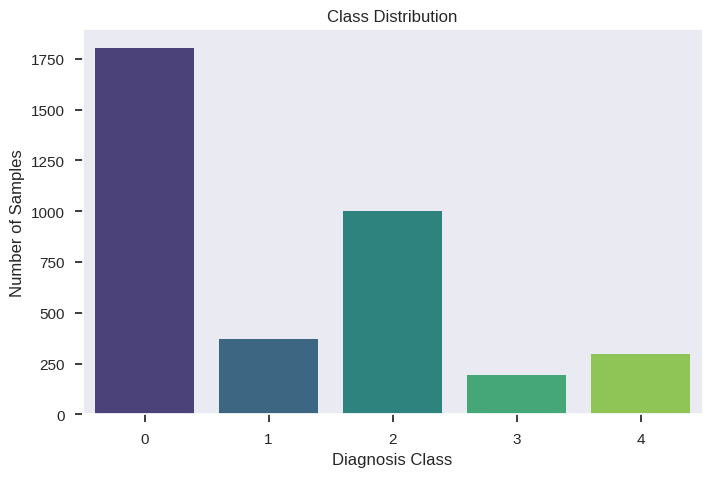

diagnosis
0    49.29
1    10.10
2    27.28
3     5.27
4     8.06
Name: count, dtype: float64

In [17]:
class_counts = train_df['diagnosis'].value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title("Class Distribution")
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Samples")
plt.grid(axis='y')
plt.show()

(class_counts / class_counts.sum() * 100).round(2)


## Pie Chart of Class Distribution

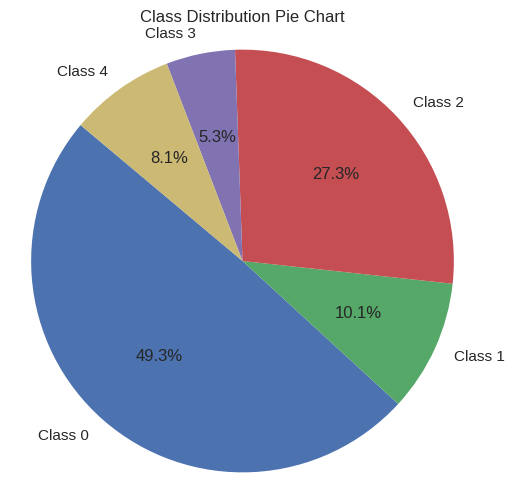

In [18]:
plt.figure(figsize=(6,6))
plt.pie(class_counts, labels=[f"Class {i}" for i in class_counts.index], autopct='%1.1f%%', startangle=140)
plt.title("Class Distribution Pie Chart")
plt.axis('equal')
plt.show()


## Class Imbalance Ratio

Calculates the ratio between the most and least frequent classes to quantify the extent of imbalance in the dataset

In [19]:
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")


Imbalance Ratio: 9.35


## Sample Fundus Images from Each Class

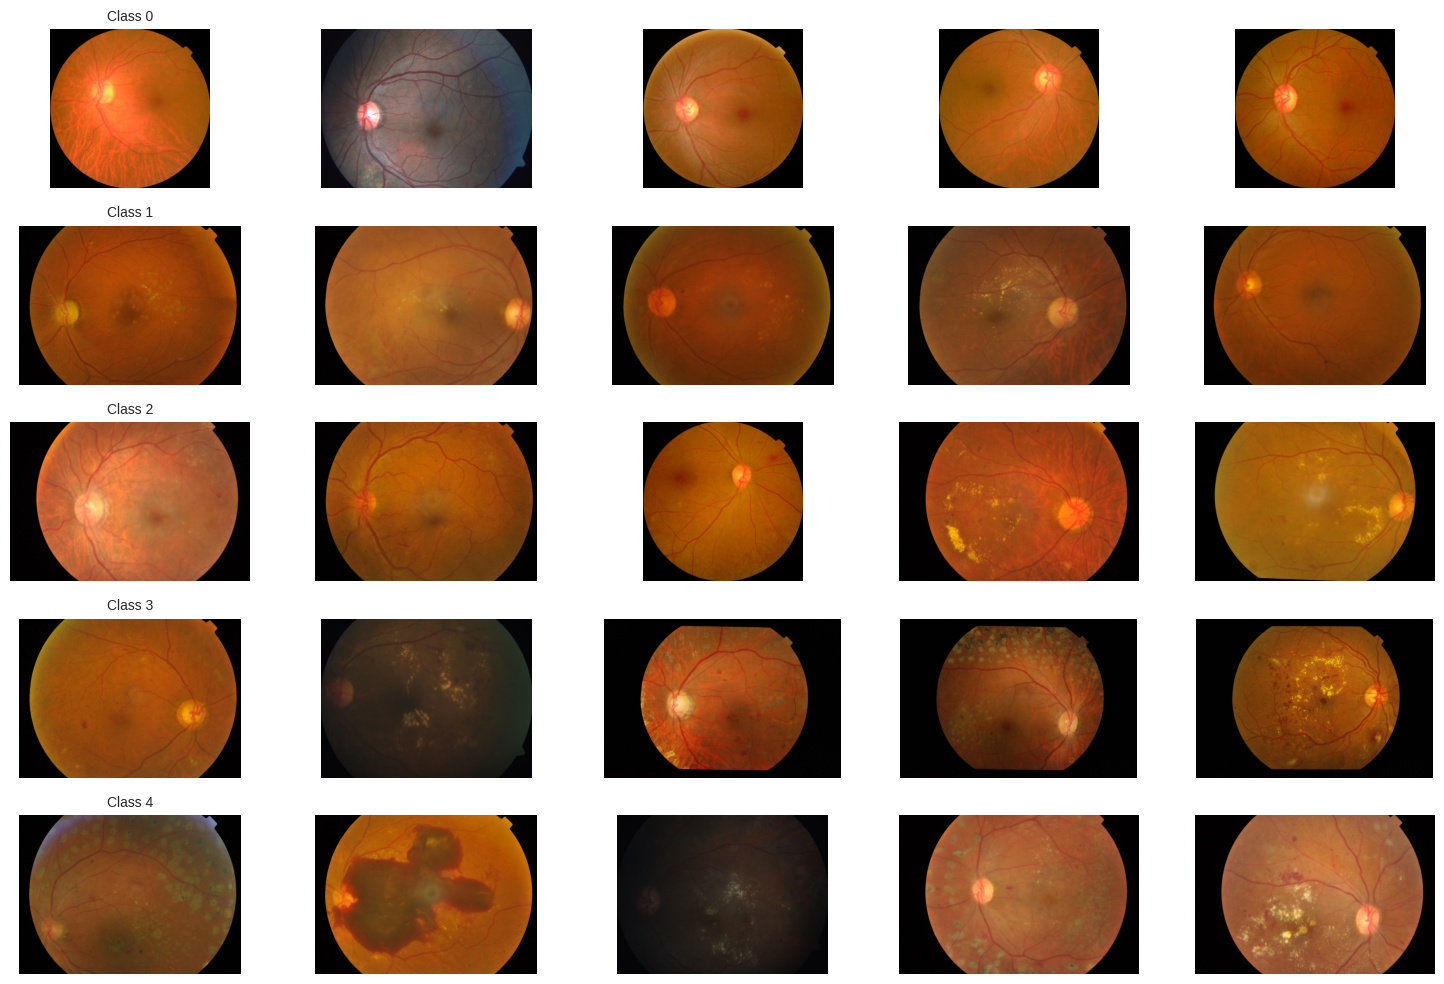

In [20]:
image_path = "../data/raw/train_images/"
fig, axs = plt.subplots(5, 5, figsize=(15, 10))
for i in range(5):
    samples = train_df[train_df['diagnosis'] == i].sample(5, random_state=42)
    for j, image_id in enumerate(samples['id_code']):
        img = Image.open(os.path.join(image_path, image_id + '.png'))
        axs[i, j].imshow(img)
        axs[i, j].axis('off')
        if j == 0:
            axs[i, j].set_title(f'Class {i}', fontsize=10)
plt.tight_layout()
plt.show()


## Image Dimensions Analysis

In [21]:
widths, heights = [], []
for image_id in tqdm(train_df['id_code'].values):
    img = Image.open(os.path.join(image_path, image_id + ".png"))
    w, h = img.size
    widths.append(w)
    heights.append(h)

train_df['width'] = widths
train_df['height'] = heights
train_df[['width', 'height']].describe()


100%|██████████| 3662/3662 [00:00<00:00, 28634.65it/s]


,width,height
count,3662.000000,3662.000000
mean,2015.176679,1526.830147
std,884.301940,542.663120
min,474.000000,358.000000
25%,1050.000000,1050.000000
50%,2144.000000,1536.000000
75%,2588.000000,1958.000000
max,4288.000000,2848.000000


## Boxplots of Image Dimensions

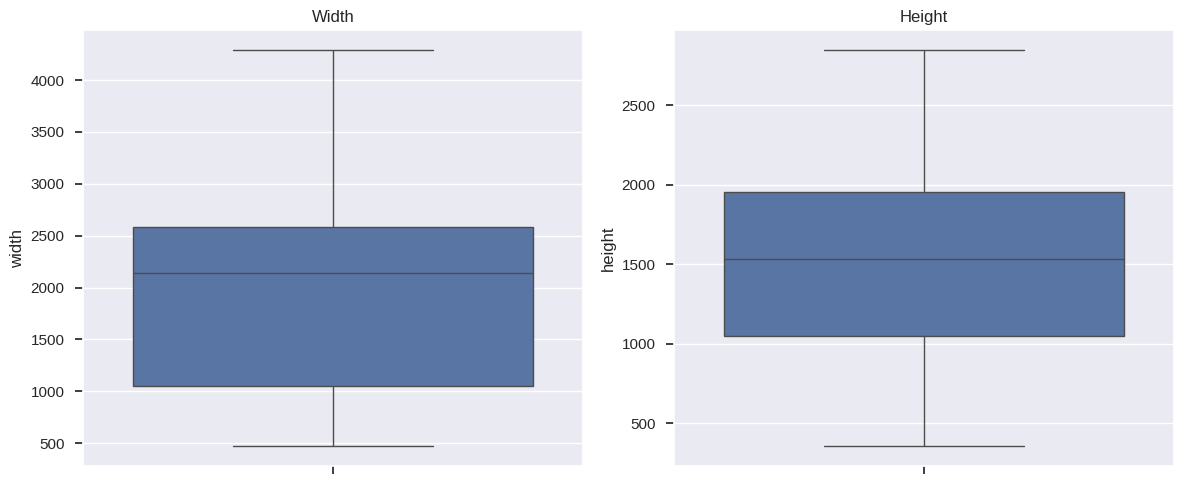

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=train_df['width'], ax=axs[0]).set_title("Width")
sns.boxplot(y=train_df['height'], ax=axs[1]).set_title("Height")
plt.tight_layout()
plt.show()


## Average RGB Values per Class

Computes the mean RGB values of 20 resized sample images from each class to analyze color distribution and lighting consistency across the dataset.

In [23]:
rgb_means = {i:[] for i in range(5)}
for i in range(5):
    sample = train_df[train_df['diagnosis'] == i].sample(20, random_state=42)
    for image_id in sample['id_code']:
        img = Image.open(os.path.join(image_path, image_id + '.png')).resize((128, 128))
        img_arr = np.array(img)
        rgb_means[i].append(img_arr.mean(axis=(0,1)))

for cls, vals in rgb_means.items():
    arr = np.array(vals)
    print(f"Class {cls} RGB mean:", arr.mean(axis=0))


Class 0 RGB mean: [102.38663025  55.19858398  20.51810608]
Class 1 RGB mean: [116.05774231  55.55195618  15.02338562]
Class 2 RGB mean: [108.92827454  59.11865234  21.28638611]
Class 3 RGB mean: [99.26710815 53.21139526 19.14374695]
Class 4 RGB mean: [106.49147034  57.3480957   20.40211792]


## Brightness Distribution Across Classes

Converts images to grayscale and computes their mean brightness to visualize how lighting conditions 

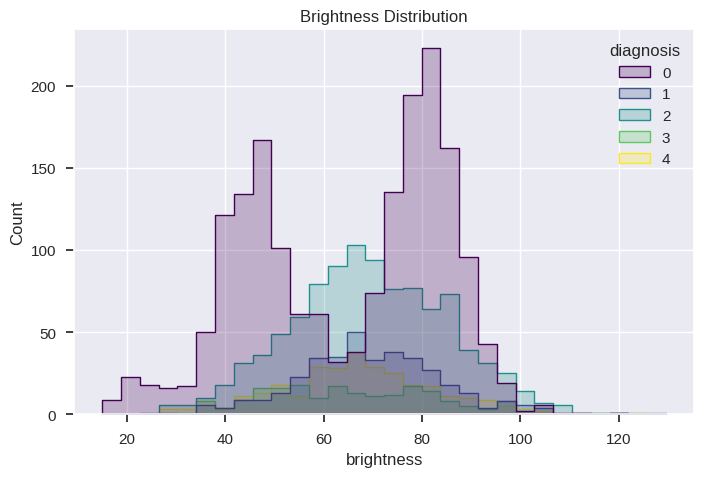

In [24]:
def calc_brightness(img):
    img = img.convert('L')
    return np.array(img).mean()

train_df['brightness'] = train_df['id_code'].apply(lambda x: calc_brightness(Image.open(os.path.join(image_path, x + '.png'))))

plt.figure(figsize=(8,5))
sns.histplot(data=train_df, x='brightness', hue='diagnosis', bins=30, palette='viridis', element='step')
plt.title("Brightness Distribution")
plt.show()


## Blurriness Analysis Using Laplacian Variance

Estimates the sharpness of each image using the variance of the Laplacian. Visualizes blurriness across classes to identify if image quality correlates with diagnosis.

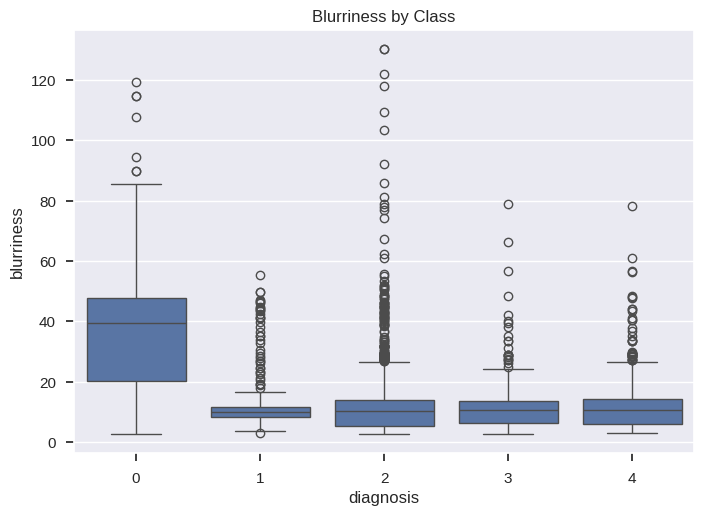

In [25]:
def detect_blur(image_id):
    img = cv2.imread(os.path.join(image_path, image_id + ".png"))
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(img_gray, cv2.CV_64F).var()

train_df['blurriness'] = train_df['id_code'].apply(detect_blur)

sns.boxplot(x='diagnosis', y='blurriness', data=train_df)
plt.title("Blurriness by Class")
plt.show()


## Missing Image File Check

In [26]:
missing = []
for img_id in train_df['id_code']:
    if not os.path.exists(os.path.join(image_path, img_id + '.png')):
        missing.append(img_id)
print("Missing Images:", missing)


Missing Images: []


## Pixel Intensity Histogram
Displays the distribution of grayscale pixel values for a sample image. This helps analyze contrast, exposure, and dynamic range within the image.

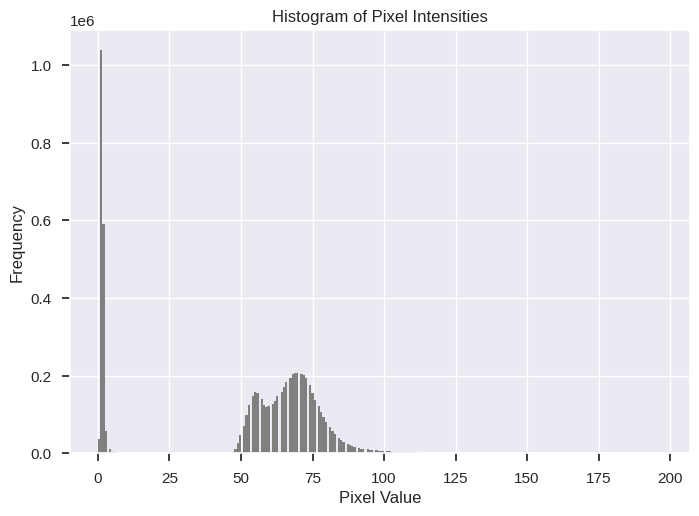

In [27]:
img = Image.open(os.path.join(image_path, train_df.iloc[0]['id_code'] + '.png')).convert('L')
plt.hist(np.array(img).ravel(), bins=256, color='gray')
plt.title("Histogram of Pixel Intensities")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


##  Skewness and Kurtosis

Calculates skewness and kurtosis for `width`, `height`, `brightness`, and `blurriness`.  
- **Skewness** indicates the asymmetry of the distribution.  
- **Kurtosis** indicates the "tailedness" or presence of outliers in the distribution.

In [28]:
for col in ['width', 'height', 'brightness', 'blurriness']:
    print(f"{col} skewness: {skew(train_df[col]):.2f}, kurtosis: {kurtosis(train_df[col]):.2f}")


width skewness: 0.14, kurtosis: -1.02
height skewness: 0.07, kurtosis: -0.71
brightness skewness: -0.23, kurtosis: -0.52
blurriness skewness: 1.02, kurtosis: 0.98


##  Pairwise Distance Heatmap

Visualizes the pairwise Euclidean distances between a sample of 100 images after resizing and flattening.  
Helps understand similarity/dissimilarity among images across all classes using raw pixel values.

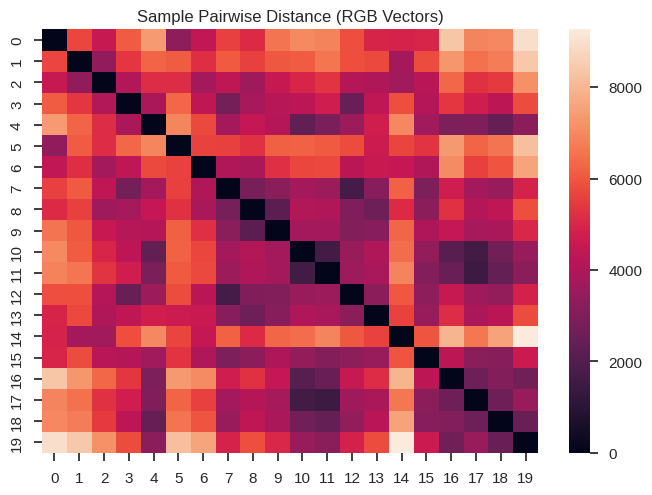

In [29]:
vectors = []
for image_id in train_df.sample(100, random_state=42)['id_code']:
    img = Image.open(os.path.join(image_path, image_id + '.png')).resize((64,64))
    vectors.append(np.array(img).flatten())
dists = pairwise_distances(vectors)
sns.heatmap(dists[:20, :20])
plt.title("Sample Pairwise Distance (RGB Vectors)")
plt.show()


##  PCA Visualization

Performs **Principal Component Analysis (PCA)** on a sample of 200 flattened images to reduce dimensionality to 2D,  
enabling visualization of the image embeddings. This gives insight into class separability and global variance structure.

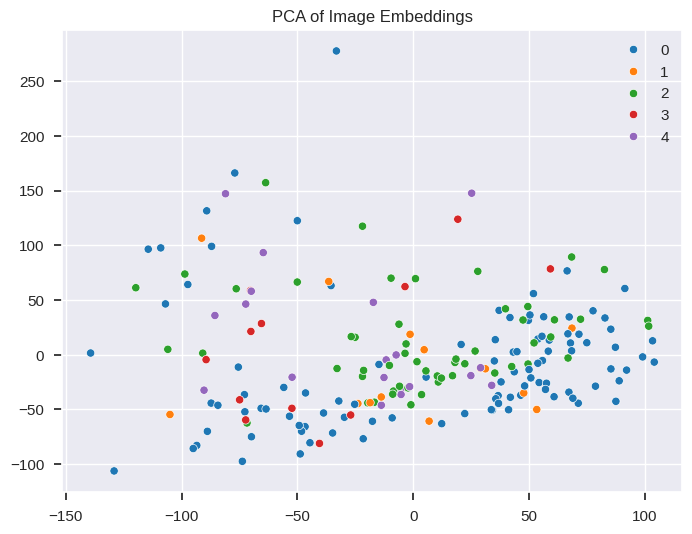

In [30]:
X = []
y = []
sample = train_df.sample(200, random_state=42)
for _, row in sample.iterrows():
    img = Image.open(os.path.join(image_path, row['id_code'] + '.png')).resize((64,64))
    X.append(np.array(img).flatten())
    y.append(row['diagnosis'])

X = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
components = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=y, palette='tab10')
plt.title("PCA of Image Embeddings")
plt.show()


##  t-SNE Visualization

Applies **t-Distributed Stochastic Neighbor Embedding (t-SNE)** to project high-dimensional image vectors  
into 2D space. Useful for visualizing local similarities and class-wise clusters in image embeddings.

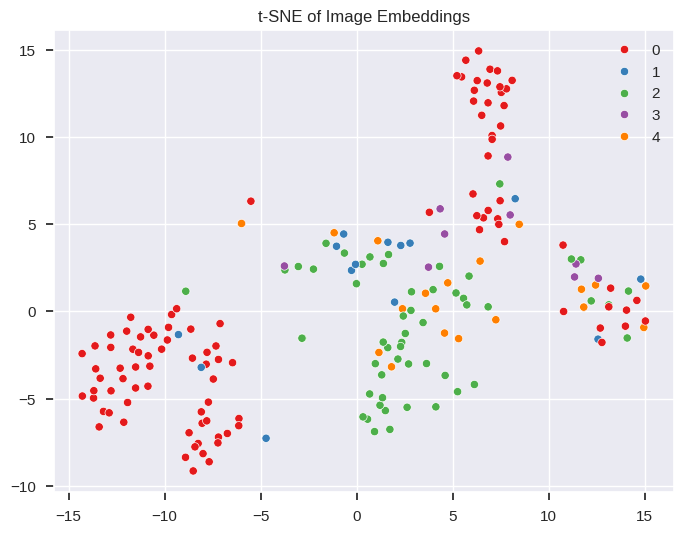

In [31]:
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=y, palette='Set1')
plt.title("t-SNE of Image Embeddings")
plt.show()
